In [2]:
import json
import math
import os
from pathlib import Path
from pprint import pprint
import sys

path = "/home/lk3591/Documents/code/RawByteClf"
os.chdir(path)
if path not in sys.path:
	sys.path.insert(0, path)

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import transformers

from src.data.cfg import BODMAS_DIST_FILE
from src.learn.train import get_config
from src.analysis import process_trainer_state
from src.utils import count_parameters, get_highest_path

Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/train.py'


2024-02-01 13:08:15,924	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.6.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-02-01 13:08:15,985	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.6.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/architectures/malconv.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/data/loaders_pt.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/helpers.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/utils.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/tokenization.py'


# These are plots for HRRFormer Top10 Classification using superpositional_scale_factor="log"

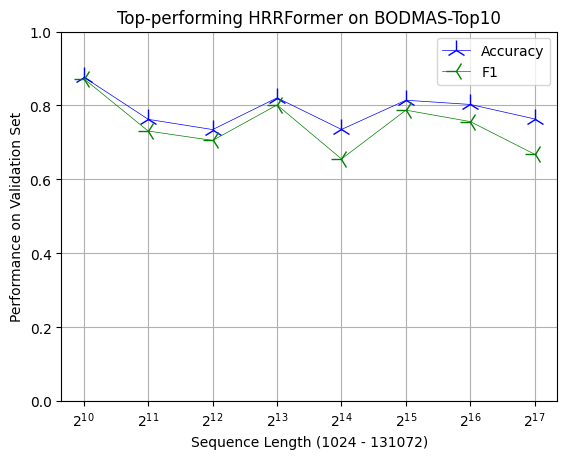

In [24]:
path = Path("./output/top10/hrrformer/")
sizes = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

data = {s: None for s in sizes}

for size in sizes:
    p = list((path / str(size)).rglob("checkpoints"))[0]
    f = get_highest_path(p, lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, train_reports = process_trainer_state(f)
    losses = np.array([r["eval_loss"] for r in validation_reports])
    # best_epoch = np.argmin(losses)
    best_epoch = np.argmax([r["eval_accuracy"] for r in validation_reports])
    loss = losses[best_epoch]
    acc = np.array([r["eval_accuracy"] for r in validation_reports])[best_epoch]
    f1 = np.array([r["eval_f1-macro"] for r in validation_reports])[best_epoch]
    data[size] = (loss, acc, f1)

#plt.plot(sizes, list(v[0] for v in data.values()), marker="1", label="Loss", color="red", linewidth=0.75)
plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Accuracy", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 1)
plt.xticks(sizes)
plt.xscale("log", base=2)
plt.xlabel("Sequence Length (1024 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing HRRFormer on BODMAS-Top10")
plt.legend()
plt.grid()

output/top10/norm/hrrformer/1024 True
output/top10/norm/hrrformer/2048 True
output/top10/norm/hrrformer/4096 True
output/top10/norm/hrrformer/8192 True
output/top10/norm/hrrformer/16384 True
output/top10/norm/hrrformer/32768 True
output/top10/norm/hrrformer/65536 True


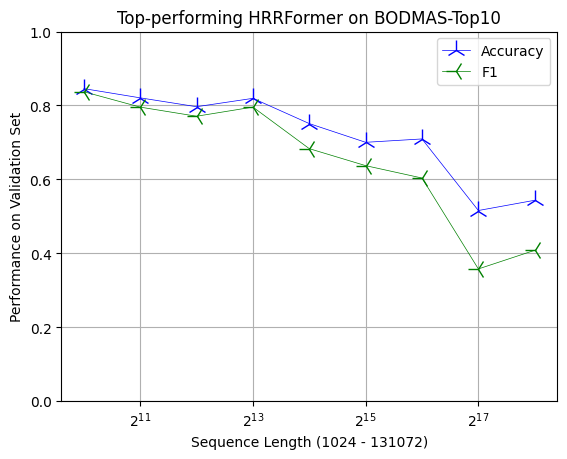

In [3]:
path = Path("./output/top10/norm/hrrformer")
sizes = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]

data = {s: None for s in sizes}

for size in sizes:
    if size == 131072:
        p = Path("/home/lk3591/Documents/code/RawByteClf/output/top10/norm/hrrformer/131072/clf/1/False/False/False/4a5ecc7b85055b3a/6cfac8a7dc321d19")
    elif size == 262144:
        p = Path("/home/lk3591/Documents/code/RawByteClf/output/top10/norm/hrrformer/262144/clf/1/False/False/False/2d292f87c92eddf9/3d16a32b5f736cd5")
    else:
        p = path / str(size)
        print(p, p.exists())

    c_path = list(p.rglob("checkpoints"))
    if c_path:
        p = c_path[0]
    else:
        continue

    f = get_highest_path(p, lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, train_reports = process_trainer_state(f)
    losses = np.array([r["eval_loss"] for r in validation_reports])
    # best_epoch = np.argmin(losses)
    best_epoch = np.argmax([r["eval_accuracy"] for r in validation_reports])
    loss = losses[best_epoch]
    acc = np.array([r["eval_accuracy"] for r in validation_reports])[best_epoch]
    f1 = np.array([r["eval_f1-macro"] for r in validation_reports])[best_epoch]
    data[size] = (loss, acc, f1)

#plt.plot(sizes, list(v[0] for v in data.values()), marker="1", label="Loss", color="red", linewidth=0.75)
plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Accuracy", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 1)
plt.xticks(sizes)
plt.xscale("log", base=2)
plt.xlabel("Sequence Length (1024 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing HRRFormer on BODMAS-Top10")
plt.legend()
plt.grid()